# **Machine Learning vs Deep Learning for Dental Image Classification**


**Dataset:** Teeth Dataset  7 Classes | 3,087 Train · 1,028 Validation · 1,028 Test

**Models Implemented:**
- **Machine Learning:** SVM (HOG + RBF Kernel) · KNN (HOG + PCA)
- **Deep Learning:** MobileNetV2 (Transfer Learning) · ResNet50 (Transfer Learning + Fine-Tuning)

**Evaluation Metrics:** Accuracy · Precision · Recall · F1-Score · Confusion Matrix


---
### 1. Importing Libraries

In [1]:
import os
import cv2
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras import layers, models, Input, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

### 2. Loading the Dataset

In [2]:
zip_path = "/content/Teeth DataSet.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir("/content/"))

['.config', 'Teeth DataSet.zip', 'Teeth_Dataset', 'sample_data']


In [4]:
train_dir = "/content/Teeth_Dataset/Training"
val_dir   = "/content/Teeth_Dataset/Validation"
test_dir  = "/content/Teeth_Dataset/Testing"

### 3. Visualize Class Distribution

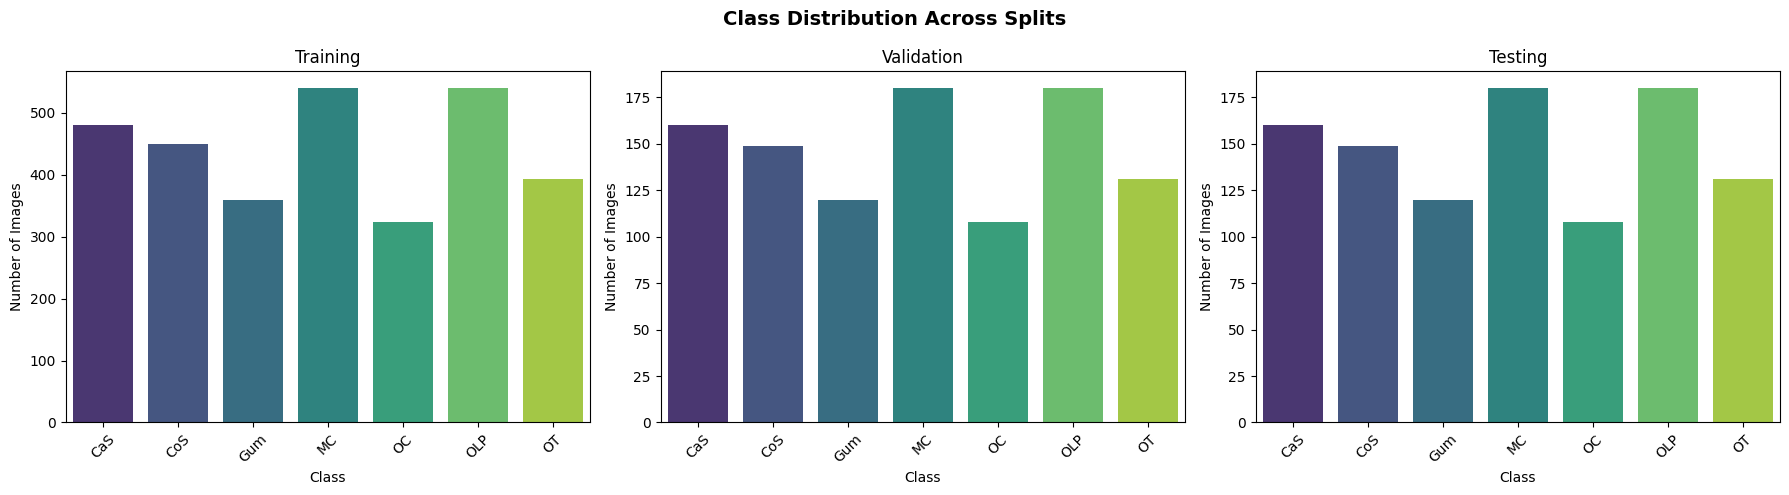

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Class Distribution Across Splits", fontsize=14, fontweight='bold')

splits = [("Training", train_dir), ("Validation", val_dir), ("Testing", test_dir)]

for ax, (split_name, split_dir) in zip(axes, splits):
    class_names_dist = sorted([d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))])
    counts = [len(os.listdir(os.path.join(split_dir, c))) for c in class_names_dist]
    sns.barplot(x=class_names_dist, y=counts, hue=class_names_dist, palette="viridis",legend=False, ax=ax)
    ax.set_title(split_name)
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of Images")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## **PART A - Machine Learning Approach**

Classical ML pipeline:
1. Load images as grayscale (64×64)
2. Extract **HOG** features (Histogram of Oriented Gradients)
3. Normalize with **StandardScaler**
4. Apply **PCA** for dimensionality reduction (used with KNN)
5. Train **SVM** and **KNN** classifiers

### 4. Image Loading & Preprocessing (ML)

In [7]:
ML_IMG_SIZE = (64, 64)

def load_images(directory):
    images, labels = [], []
    class_names = sorted(os.listdir(directory))

    for class_name in class_names:
        class_path = os.path.join(directory, class_name)

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, ML_IMG_SIZE)

            images.append(img)
            labels.append(class_name)

    return np.array(images), np.array(labels), class_names

X_train_ml, y_train_str, class_names = load_images(train_dir)
X_val_ml, y_val_str, _ = load_images(val_dir)
X_test_ml, y_test_str, _ = load_images(test_dir)

print(f"Classes ({len(class_names)}): {class_names}")
print(f"Train: {len(X_train_ml)} | Val: {len(X_val_ml)} | Test: {len(X_test_ml)}")

Classes (7): ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
Train: 3087 | Val: 1028 | Test: 1028


In [8]:
le = LabelEncoder()
le.fit(class_names)

y_train_ml = le.transform(y_train_str)
y_val_ml = le.transform(y_val_str)
y_test_ml = le.transform(y_test_str)

### 5. HOG Feature Extraction

In [9]:
def extract_hog(images):
    features = []
    for img in images:
        feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            feature_vector=True
        )
        features.append(feat)
    return np.array(features)

X_train_hog = extract_hog(X_train_ml)
X_val_hog = extract_hog(X_val_ml)
X_test_hog = extract_hog(X_test_ml)

In [10]:
scaler = StandardScaler()

X_train_hog_scaled = scaler.fit_transform(X_train_hog)
X_val_hog_scaled = scaler.transform(X_val_hog)
X_test_hog_scaled = scaler.transform(X_test_hog)

In [11]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_hog_scaled)
X_val_pca = pca.transform(X_val_hog_scaled)
X_test_pca = pca.transform(X_test_hog_scaled)

print(f"HOG dim: {X_train_hog_scaled.shape[1]}")
print(f"After PCA: {X_train_pca.shape[1]}")

HOG dim: 1764
After PCA: 458


### 6. ML Model 1 - Support Vector Machine (SVM)

In [12]:
svm_model = SVC(kernel='rbf', C=10, gamma='scale')
svm_model.fit(X_train_hog_scaled, y_train_ml)

SVC(C=10)

### 7. ML Model 2 - K-Nearest Neighbors (KNN)

In [13]:
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean', n_jobs=-1)
knn_model.fit(X_train_pca, y_train_ml)

KNeighborsClassifier(metric='euclidean', n_jobs=-1, weights='distance')

### 8. ML Evaluation

In [14]:
def evaluate_ml(model, X, y, name):
    y_pred = model.predict(X)
    print(f"# {name}")
    print("Accuracy:", round(accuracy_score(y, y_pred), 4))
    print(classification_report(y, y_pred, target_names=class_names))

    cm = confusion_matrix(y, y_pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} - Confusion Matrix", fontweight='bold')
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return y_pred

# SVM (Validation)
Accuracy: 0.6031
              precision    recall  f1-score   support

         CaS       0.58      0.69      0.63       160
         CoS       0.72      0.79      0.75       149
         Gum       0.58      0.39      0.47       120
          MC       0.56      0.58      0.57       180
          OC       0.64      0.50      0.56       108
         OLP       0.55      0.61      0.58       180
          OT       0.62      0.58      0.60       131

    accuracy                           0.60      1028
   macro avg       0.61      0.59      0.59      1028
weighted avg       0.60      0.60      0.60      1028



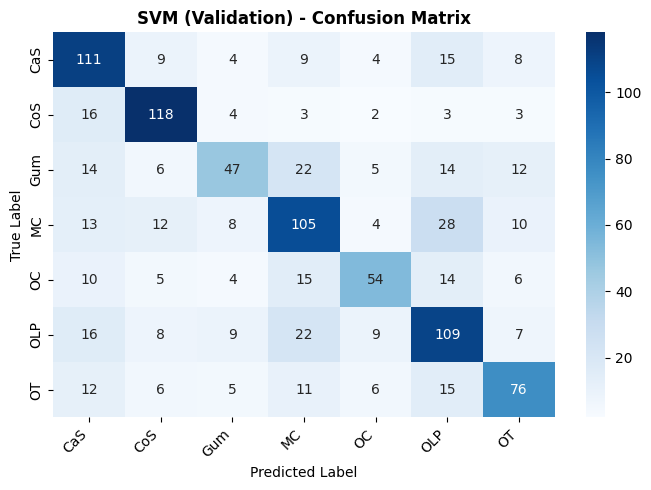

# KNN (Validation)
Accuracy: 0.573
              precision    recall  f1-score   support

         CaS       0.91      0.33      0.49       160
         CoS       0.69      0.80      0.74       149
         Gum       0.84      0.30      0.44       120
          MC       0.64      0.54      0.59       180
          OC       0.57      0.55      0.56       108
         OLP       0.41      0.76      0.53       180
          OT       0.53      0.67      0.59       131

    accuracy                           0.57      1028
   macro avg       0.66      0.56      0.56      1028
weighted avg       0.65      0.57      0.56      1028



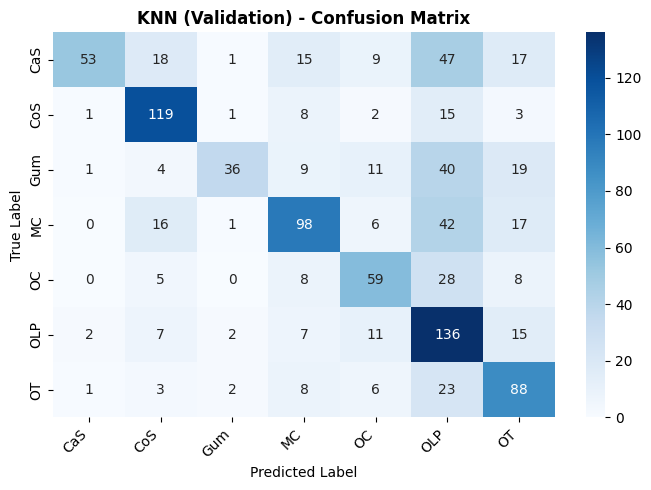

array([6, 6, 0, ..., 5, 6, 6])

In [15]:
# Validation performance
evaluate_ml(svm_model, X_val_hog_scaled, y_val_ml, "SVM (Validation)")
evaluate_ml(knn_model, X_val_pca, y_val_ml, "KNN (Validation)")

# SVM (Test)
Accuracy: 0.6304
              precision    recall  f1-score   support

         CaS       0.59      0.72      0.65       160
         CoS       0.73      0.72      0.72       149
         Gum       0.66      0.42      0.51       120
          MC       0.58      0.67      0.62       180
          OC       0.66      0.56      0.61       108
         OLP       0.57      0.60      0.58       180
          OT       0.71      0.65      0.68       131

    accuracy                           0.63      1028
   macro avg       0.64      0.62      0.63      1028
weighted avg       0.64      0.63      0.63      1028



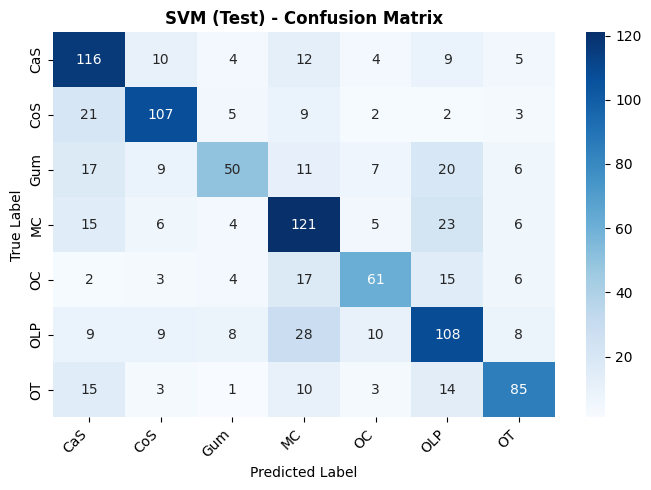

# KNN (Test)
Accuracy: 0.5856
              precision    recall  f1-score   support

         CaS       0.95      0.35      0.51       160
         CoS       0.69      0.72      0.71       149
         Gum       0.86      0.35      0.50       120
          MC       0.59      0.57      0.58       180
          OC       0.57      0.57      0.57       108
         OLP       0.45      0.81      0.57       180
          OT       0.57      0.66      0.61       131

    accuracy                           0.59      1028
   macro avg       0.67      0.58      0.58      1028
weighted avg       0.66      0.59      0.58      1028



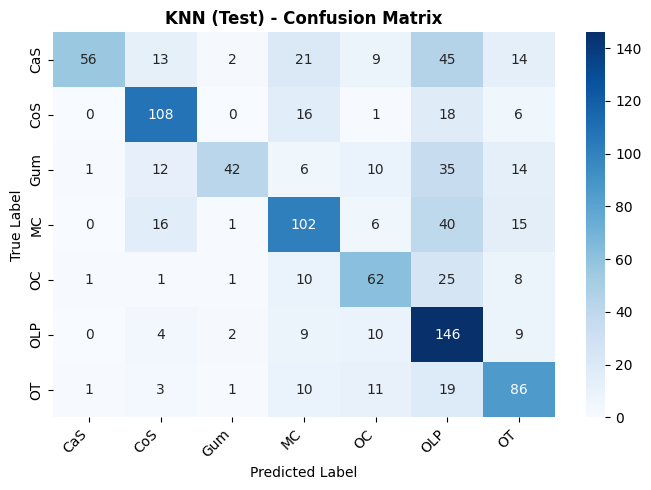

In [16]:
# Test performance
y_pred_svm = evaluate_ml(svm_model, X_test_hog_scaled, y_test_ml, "SVM (Test)")
y_pred_knn = evaluate_ml(knn_model, X_test_pca, y_test_ml, "KNN (Test)")

In [17]:
def get_metrics(y_true, y_pred):
    return {
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted'), 4),
    }

svm_metrics = get_metrics(y_test_ml, y_pred_svm)
knn_metrics = get_metrics(y_test_ml, y_pred_knn)

print("SVM metrics:", svm_metrics)
print("KNN metrics:", knn_metrics)

SVM metrics: {'Accuracy': 0.6304, 'Precision': 0.6364, 'Recall': 0.6304, 'F1-Score': 0.628}
KNN metrics: {'Accuracy': 0.5856, 'Precision': 0.6599, 'Recall': 0.5856, 'F1-Score': 0.579}


---
## **PART B - Deep Learning Approach (Transfer Learning)**

CNN pipeline:
1. Load images via **ImageDataGenerator** (224×224, with augmentation for training)
2. **MobileNetV2** - pretrained on ImageNet, frozen base + custom head
3. **ResNet50** - pretrained on ImageNet, frozen → then **fine-tuned** (last 30 layers unfrozen)

### 9. Data Preprocessing & Augmentation (DL)

In [18]:
DL_IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# MobileNetV2 generators
train_datagen_mobile = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen_mobile  = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)
test_datagen_mobile = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

train_gen_mobile = train_datagen_mobile.flow_from_directory(
    train_dir, target_size=DL_IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED)
val_gen_mobile = val_datagen_mobile.flow_from_directory(
    val_dir, target_size=DL_IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED)
test_gen_mobile = test_datagen_mobile.flow_from_directory(
    test_dir, target_size=DL_IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# ResNet50 generators
train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen_resnet  = ImageDataGenerator(preprocessing_function=resnet_preprocess)
test_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)

train_gen_resnet = train_datagen_resnet.flow_from_directory(
    train_dir, target_size=DL_IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED)
val_gen_resnet = val_datagen_resnet.flow_from_directory(
    val_dir, target_size=DL_IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED)
test_gen_resnet = test_datagen_resnet.flow_from_directory(
    test_dir, target_size=DL_IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)


Found 3087 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.
Found 3087 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.


### 10. Data Augmentation Visualization

Found 3087 images belonging to 7 classes.


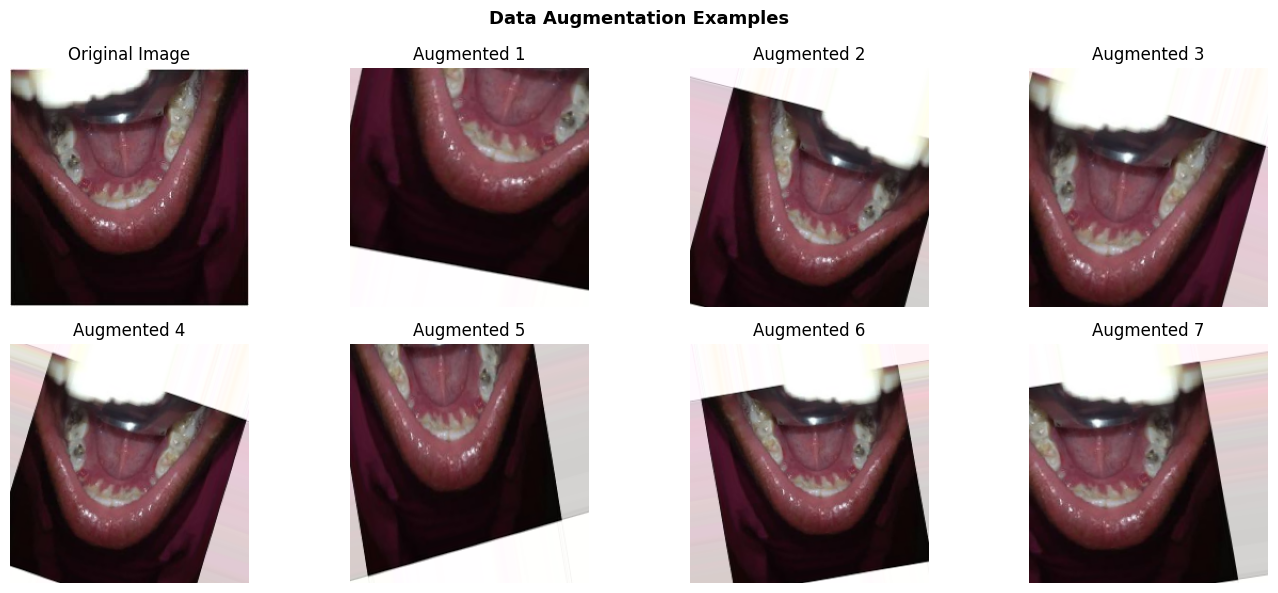

In [52]:
display_datagen = ImageDataGenerator(rescale=1./255)
display_gen = display_datagen.flow_from_directory(
    train_dir, target_size=DL_IMG_SIZE, batch_size=1, class_mode='categorical')

images, labels = next(display_gen)
original_image = images[0]

temp_datagen = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

original_image_expanded = np.expand_dims(original_image, axis=0)

plt.figure(figsize=(14, 6))
plt.subplot(2, 4, 1)
plt.imshow(original_image)
plt.title('Original Image')
plt.axis('off')

for i, batch in enumerate(temp_datagen.flow(original_image_expanded, batch_size=1)):
    if i == 7:
        break
    plt.subplot(2, 4, i + 2)
    plt.imshow(batch[0])
    plt.title(f'Augmented {i+1}')
    plt.axis('off')

plt.suptitle("Data Augmentation Examples", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 11. DL Model 1 - MobileNetV2 (Transfer Learning)

**Architecture:**
- Base: MobileNetV2 pretrained on ImageNet (frozen)
- Head: GlobalAveragePooling → Dense(256, ReLU) → Dropout(0.3) → Dense(7, Softmax)
- Optimizer: Adam | Loss: Categorical Crossentropy

In [53]:
base_model_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_mobile.trainable = False

model_mobile = models.Sequential([
    base_model_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])

model_mobile.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_mobile = ModelCheckpoint(
    "best_mobilenet.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

model_mobile.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 12. Training MobileNetV2

In [54]:
history_mobile = model_mobile.fit(
    train_gen_mobile,
    validation_data=val_gen_mobile,
    epochs=20,
    callbacks=[checkpoint_mobile]
)

Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.3923 - loss: 1.6611
Epoch 1: val_accuracy improved from None to 0.72860, saving model to best_mobilenet.h5



Epoch 1: finished saving model to best_mobilenet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 86s 689ms/step - accuracy: 0.5028 - loss: 1.3399 - val_accuracy: 0.7286 - val_loss: 0.8187
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.6508 - loss: 0.9420
Epoch 2: val_accuracy improved from 0.72860 to 0.77140, saving model to best_mobilenet.h5



Epoch 2: finished saving model to best_mobilenet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 394ms/step - accuracy: 0.6770 - loss: 0.8897 - val_accuracy: 0.7714 - val_loss: 0.6548
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.7535 - loss: 0.7097
Epoch 3: val_accuracy improved from 0.77140 to 0.85409, saving model to best_mobilenet.h5



Epoch 3: finished saving model to best_mobilenet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 397ms/step - accuracy: 0.7457 - loss: 0.7165 - val_accuracy: 0.8541 - val_loss: 0.4882
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.7819 - loss: 0.6183
Epoch 4: val_accuracy improved from 0.85409 to 0.85603, saving model to best_mobilenet.h5



Epoch 4: finished saving model to best_mobilenet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 398ms/step - accuracy: 0.7881 - loss: 0.6002 - val_accuracy: 0.8560 - val_loss: 0.4470
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.8067 - loss: 0.5386
Epoch 5: val_accuracy improved from 0.85603 to 0.89105, saving model to best_mobilenet.h5


...


Epoch 10: finished saving model to best_mobilenet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 406ms/step - accuracy: 0.8882 - loss: 0.3093 - val_accuracy: 0.9494 - val_loss: 0.1777
Epoch 11/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.8956 - loss: 0.3056
Epoch 11: val_accuracy did not improve from 0.94942
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 405ms/step - accuracy: 0.9028 - loss: 0.2904 - val_accuracy: 0.9416 - val_loss: 0.1728
Epoch 12/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9168 - loss: 0.2554
Epoch 12: val_accuracy did not improve from 0.94942
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 405ms/step - accuracy: 0.9112 - loss: 0.2700 - val_accuracy: 0.9426 - val_loss: 0.1824
Epoch 13/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9082 - loss: 0.2459
Epoch 13: val_accuracy did not improve from 0.94942
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 403ms/step - accuracy: 0.9083 - loss: 0.2494 - val_accuracy: 0.9455 - val_loss: 0.1659
Epoch 14/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - ac


Epoch 15: finished saving model to best_mobilenet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 406ms/step - accuracy: 0.9142 - loss: 0.2472 - val_accuracy: 0.9543 - val_loss: 0.1567
Epoch 16/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9286 - loss: 0.2227
Epoch 16: val_accuracy improved from 0.95428 to 0.95914, saving model to best_mobilenet.h5



Epoch 16: finished saving model to best_mobilenet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 418ms/step - accuracy: 0.9281 - loss: 0.2222 - val_accuracy: 0.9591 - val_loss: 0.1287
Epoch 17/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9333 - loss: 0.1923
Epoch 17: val_accuracy improved from 0.95914 to 0.96401, saving model to best_mobilenet.h5



Epoch 17: finished saving model to best_mobilenet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 417ms/step - accuracy: 0.9271 - loss: 0.2135 - val_accuracy: 0.9640 - val_loss: 0.1183
Epoch 18/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9233 - loss: 0.2221
Epoch 18: val_accuracy did not improve from 0.96401
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 404ms/step - accuracy: 0.9274 - loss: 0.2091 - val_accuracy: 0.9601 - val_loss: 0.1163
Epoch 19/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9348 - loss: 0.1922
Epoch 19: val_accuracy did not improve from 0.96401
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 399ms/step - accuracy: 0.9372 - loss: 0.1875 - val_accuracy: 0.9533 - val_loss: 0.1363
Epoch 20/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9228 - loss: 0.2144
Epoch 20: val_accuracy improved from 0.96401 to 0.96887, saving model to best_mobilenet.h5



Epoch 20: finished saving model to best_mobilenet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 406ms/step - accuracy: 0.9261 - loss: 0.2117 - val_accuracy: 0.9689 - val_loss: 0.1022


### 13. DL Model 2 - ResNet50 (Transfer Learning + Fine-Tuning)

Phase 1. Feature Extraction: Base frozen, train only the custom head\
Phase 2. Fine-Tuning: Unfreeze last 30 layers, retrain with very low LR (1e-5)

In [55]:
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_resnet.trainable = False

model_resnet = models.Sequential([
    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])

model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_resnet = ModelCheckpoint(
    "best_resnet.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 530,439 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

### Phase 1. ResNet50 Initial Training

In [56]:
history_resnet = model_resnet.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=20,
    callbacks=[checkpoint_resnet]
)

Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.5057 - loss: 1.6249
Epoch 1: val_accuracy improved from None to 0.83560, saving model to best_resnet.h5



Epoch 1: finished saving model to best_resnet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 71s 580ms/step - accuracy: 0.6265 - loss: 1.1872 - val_accuracy: 0.8356 - val_loss: 0.4563
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.7973 - loss: 0.5705
Epoch 2: val_accuracy improved from 0.83560 to 0.94455, saving model to best_resnet.h5



Epoch 2: finished saving model to best_resnet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 46s 469ms/step - accuracy: 0.8147 - loss: 0.5335 - val_accuracy: 0.9446 - val_loss: 0.1791
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.8821 - loss: 0.3386
Epoch 3: val_accuracy improved from 0.94455 to 0.94942, saving model to best_resnet.h5



Epoch 3: finished saving model to best_resnet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 44s 447ms/step - accuracy: 0.8769 - loss: 0.3620 - val_accuracy: 0.9494 - val_loss: 0.1466
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9078 - loss: 0.2757
Epoch 4: val_accuracy improved from 0.94942 to 0.97957, saving model to best_resnet.h5



Epoch 4: finished saving model to best_resnet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 42s 436ms/step - accuracy: 0.8967 - loss: 0.3016 - val_accuracy: 0.9796 - val_loss: 0.0892
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9164 - loss: 0.2454
Epoch 5: val_accuracy did not improve from 0.97957
97/97 ━━━━━━━━━━━━━━━━━━━━ 43s 442ms/step - accuracy: 0.9109 - loss: 0.2546 - val_accuracy: 0.9776 - val_loss: 0.0686
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9255 - loss: 0.2223
Epoch 6: val_accuracy did not improve from 0.97957
97/97 ━━━━━━━━━━━━━━━━━━━━ 42s 438ms/step - accuracy: 0.9187 - loss: 0.2344 - val_accuracy: 0.9776 - val_loss: 0.0753
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9374 - loss: 0.1991
Epoch 7: val_accuracy improved from 0.97957 to 0.98346, saving model to best_resnet.h5



Epoch 7: finished saving model to best_resnet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 44s 453ms/step - accuracy: 0.9316 - loss: 0.1967 - val_accuracy: 0.9835 - val_loss: 0.0585
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9306 - loss: 0.1907
Epoch 8: val_accuracy improved from 0.98346 to 0.98833, saving model to best_resnet.h5



Epoch 8: finished saving model to best_resnet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 43s 442ms/step - accuracy: 0.9378 - loss: 0.1697 - val_accuracy: 0.9883 - val_loss: 0.0367
Epoch 9/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9449 - loss: 0.1660
Epoch 9: val_accuracy did not improve from 0.98833
97/97 ━━━━━━━━━━━━━━━━━━━━ 43s 438ms/step - accuracy: 0.9417 - loss: 0.1713 - val_accuracy: 0.9786 - val_loss: 0.0565
Epoch 10/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9537 - loss: 0.1312
Epoch 10: val_accuracy improved from 0.98833 to 0.99416, saving model to best_resnet.h5



Epoch 10: finished saving model to best_resnet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 44s 446ms/step - accuracy: 0.9508 - loss: 0.1463 - val_accuracy: 0.9942 - val_loss: 0.0266
Epoch 11/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9667 - loss: 0.1031
Epoch 11: val_accuracy did not improve from 0.99416
97/97 ━━━━━━━━━━━━━━━━━━━━ 43s 443ms/step - accuracy: 0.9615 - loss: 0.1158 - val_accuracy: 0.9922 - val_loss: 0.0296
Epoch 12/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9553 - loss: 0.1326
Epoch 12: val_accuracy did not improve from 0.99416
97/97 ━━━━━━━━━━━━━━━━━━━━ 44s 449ms/step - accuracy: 0.9540 - loss: 0.1252 - val_accuracy: 0.9825 - val_loss: 0.0532
Epoch 13/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9548 - loss: 0.1585
Epoch 13: val_accuracy did not improve from 0.99416
97/97 ━━━━━━━━━━━━━━━━━━━━ 42s 435ms/step - accuracy: 0.9527 - loss: 0.1413 - val_accuracy: 0.9864 - val_loss: 0.0342
Epoch 14/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accur


Epoch 17: finished saving model to best_resnet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 82s 443ms/step - accuracy: 0.9602 - loss: 0.1201 - val_accuracy: 0.9951 - val_loss: 0.0178
Epoch 18/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9666 - loss: 0.1117
Epoch 18: val_accuracy did not improve from 0.99514
97/97 ━━━━━━━━━━━━━━━━━━━━ 43s 447ms/step - accuracy: 0.9611 - loss: 0.1262 - val_accuracy: 0.9864 - val_loss: 0.0323
Epoch 19/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9691 - loss: 0.0841
Epoch 19: val_accuracy did not improve from 0.99514
97/97 ━━━━━━━━━━━━━━━━━━━━ 43s 443ms/step - accuracy: 0.9676 - loss: 0.0907 - val_accuracy: 0.9942 - val_loss: 0.0189
Epoch 20/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9705 - loss: 0.0910
Epoch 20: val_accuracy did not improve from 0.99514
97/97 ━━━━━━━━━━━━━━━━━━━━ 45s 467ms/step - accuracy: 0.9705 - loss: 0.0892 - val_accuracy: 0.9932 - val_loss: 0.0195


### Phase 2. ResNet50 Fine-Tuning

In [57]:
base_model_resnet.trainable = True
for layer in base_model_resnet.layers[:-30]:
    layer.trainable = False

model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [58]:
history_resnet_finetune = model_resnet.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=10,
    callbacks=[checkpoint_resnet]
)

Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9343 - loss: 0.1955
Epoch 1: val_accuracy improved from 0.99514 to 0.99611, saving model to best_resnet.h5



Epoch 1: finished saving model to best_resnet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 80s 605ms/step - accuracy: 0.9423 - loss: 0.1648 - val_accuracy: 0.9961 - val_loss: 0.0234
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9538 - loss: 0.1216
Epoch 2: val_accuracy did not improve from 0.99611
97/97 ━━━━━━━━━━━━━━━━━━━━ 46s 469ms/step - accuracy: 0.9572 - loss: 0.1116 - val_accuracy: 0.9912 - val_loss: 0.0215
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9552 - loss: 0.1325
Epoch 3: val_accuracy did not improve from 0.99611
97/97 ━━━━━━━━━━━━━━━━━━━━ 44s 458ms/step - accuracy: 0.9650 - loss: 0.1029 - val_accuracy: 0.9951 - val_loss: 0.0130
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9650 - loss: 0.0907
Epoch 4: val_accuracy improved from 0.99611 to 0.99805, saving model to best_resnet.h5



Epoch 4: finished saving model to best_resnet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 46s 477ms/step - accuracy: 0.9686 - loss: 0.0797 - val_accuracy: 0.9981 - val_loss: 0.0095
Epoch 5/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9664 - loss: 0.0997
Epoch 5: val_accuracy improved from 0.99805 to 0.99903, saving model to best_resnet.h5



Epoch 5: finished saving model to best_resnet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 48s 491ms/step - accuracy: 0.9718 - loss: 0.0839 - val_accuracy: 0.9990 - val_loss: 0.0069
Epoch 6/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9781 - loss: 0.0669
Epoch 6: val_accuracy did not improve from 0.99903
97/97 ━━━━━━━━━━━━━━━━━━━━ 45s 459ms/step - accuracy: 0.9789 - loss: 0.0638 - val_accuracy: 0.9990 - val_loss: 0.0055
Epoch 7/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9741 - loss: 0.0794
Epoch 7: val_accuracy did not improve from 0.99903
97/97 ━━━━━━━━━━━━━━━━━━━━ 45s 461ms/step - accuracy: 0.9770 - loss: 0.0606 - val_accuracy: 0.9990 - val_loss: 0.0053
Epoch 8/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9820 - loss: 0.0584
Epoch 8: val_accuracy improved from 0.99903 to 1.00000, saving model to best_resnet.h5



Epoch 8: finished saving model to best_resnet.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 44s 456ms/step - accuracy: 0.9835 - loss: 0.0546 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 9/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9855 - loss: 0.0431
Epoch 9: val_accuracy did not improve from 1.00000
97/97 ━━━━━━━━━━━━━━━━━━━━ 45s 466ms/step - accuracy: 0.9835 - loss: 0.0475 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 10/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9825 - loss: 0.0412
Epoch 10: val_accuracy did not improve from 1.00000
97/97 ━━━━━━━━━━━━━━━━━━━━ 44s 452ms/step - accuracy: 0.9851 - loss: 0.0387 - val_accuracy: 0.9990 - val_loss: 0.0036


## 14. DL Evaluation

In [59]:
y_pred_mob = model_mobile.predict(test_gen_mobile)
y_pred_mob_classes = np.argmax(y_pred_mob, axis=1)
y_true_mob = test_gen_mobile.classes
dl_class_names = list(test_gen_mobile.class_indices.keys())

y_pred_res = model_resnet.predict(test_gen_resnet)
y_pred_res_classes = np.argmax(y_pred_res, axis=1)
y_true_res = test_gen_resnet.classes

33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step


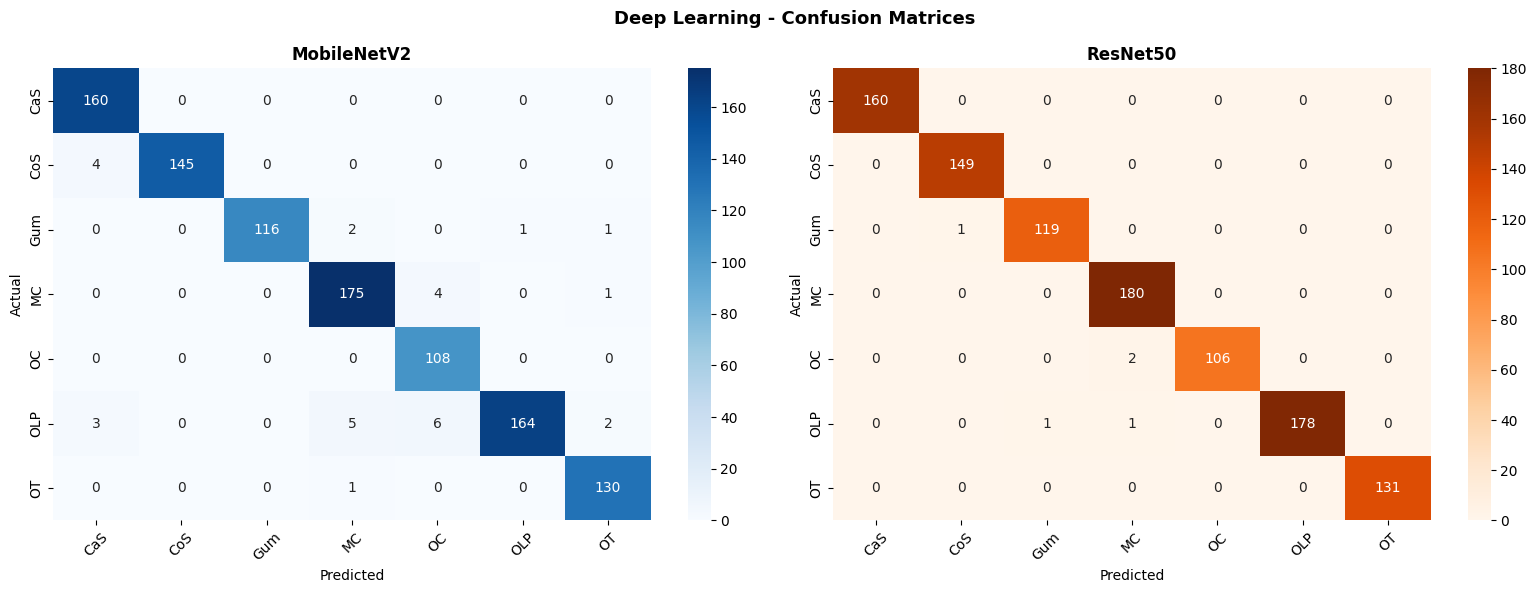

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Deep Learning - Confusion Matrices", fontsize=13, fontweight='bold')

for ax, (y_true, y_pred, title, cmap) in zip(axes, [
    (y_true_mob, y_pred_mob_classes, "MobileNetV2", "Blues"),
    (y_true_res, y_pred_res_classes, "ResNet50",    "Oranges"),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=dl_class_names, yticklabels=dl_class_names, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

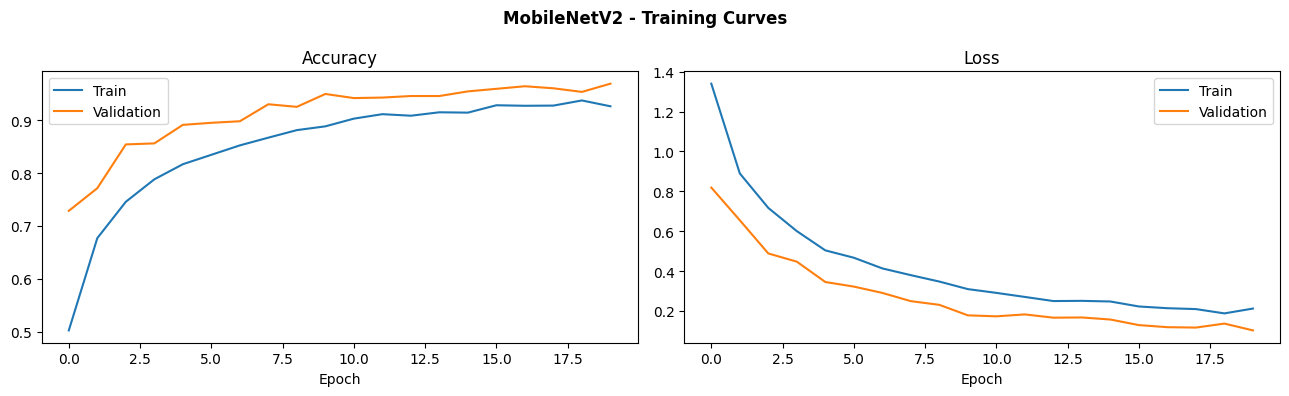

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("MobileNetV2 - Training Curves", fontsize=12, fontweight='bold')

axes[0].plot(history_mobile.history['accuracy'],     label='Train')
axes[0].plot(history_mobile.history['val_accuracy'], label='Validation')
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_mobile.history['loss'],     label='Train')
axes[1].plot(history_mobile.history['val_loss'], label='Validation')
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

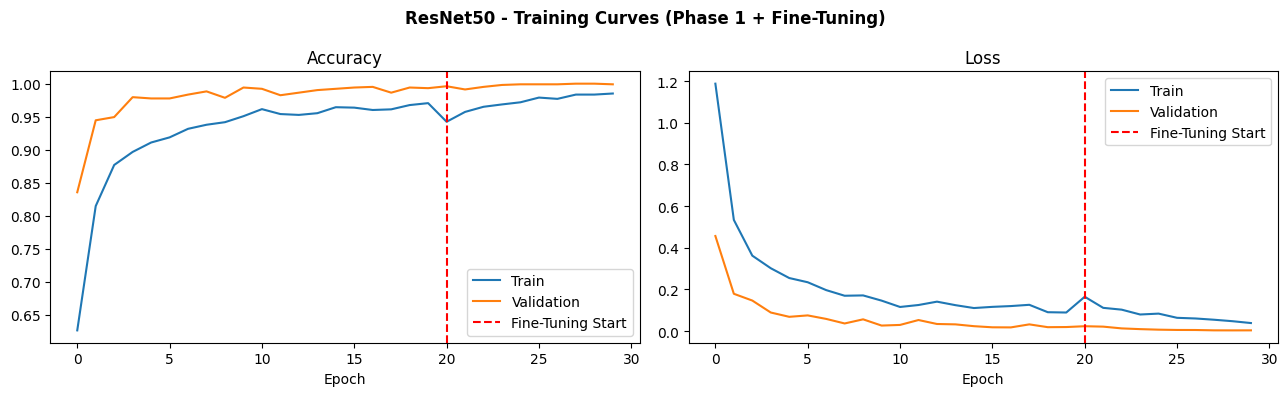

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("ResNet50 - Training Curves (Phase 1 + Fine-Tuning)", fontsize=12, fontweight='bold')

acc = history_resnet.history['accuracy'] + history_resnet_finetune.history['accuracy']
val_acc = history_resnet.history['val_accuracy'] + history_resnet_finetune.history['val_accuracy']
loss = history_resnet.history['loss'] + history_resnet_finetune.history['loss']
val_loss = history_resnet.history['val_loss'] + history_resnet_finetune.history['val_loss']
ft_start = len(history_resnet.history['accuracy'])

axes[0].plot(acc, label='Train')
axes[0].plot(val_acc, label='Validation')
axes[0].axvline(ft_start, color='red', linestyle='--', label='Fine-Tuning Start')
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(loss, label='Train')
axes[1].plot(val_loss, label='Validation')
axes[1].axvline(ft_start, color='red', linestyle='--', label='Fine-Tuning Start')
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [65]:
report_mob = classification_report(y_true_mob, y_pred_mob_classes, output_dict=True)
report_res = classification_report(y_true_res, y_pred_res_classes, output_dict=True)

mob_metrics = {
    'Accuracy' : round(accuracy_score(y_true_mob, y_pred_mob_classes), 4),
    'Precision': round(report_mob['weighted avg']['precision'], 4),
    'Recall'   : round(report_mob['weighted avg']['recall'], 4),
    'F1-Score' : round(report_mob['weighted avg']['f1-score'], 4),
}
res_metrics = {
    'Accuracy' : round(accuracy_score(y_true_res, y_pred_res_classes), 4),
    'Precision': round(report_res['weighted avg']['precision'], 4),
    'Recall'   : round(report_res['weighted avg']['recall'], 4),
    'F1-Score' : round(report_res['weighted avg']['f1-score'], 4),
}

print("MobileNetV2:", mob_metrics)
print("ResNet50   :", res_metrics)

MobileNetV2: {'Accuracy': 0.9708, 'Precision': 0.9721, 'Recall': 0.9708, 'F1-Score': 0.9708}
ResNet50   : {'Accuracy': 0.9951, 'Precision': 0.9952, 'Recall': 0.9951, 'F1-Score': 0.9951}


---
## **PART C - Comparison: ML vs Deep Learning**

Full comparison across all 4 models on the **Test Set**.

In [68]:
comparison_data = [
    {'Model': 'SVM (HOG + RBF)', **svm_metrics},
    {'Model': 'KNN (K=5, HOG + PCA)', **knn_metrics},
    {'Model': 'MobileNetV2 (Transfer Learning)', **mob_metrics},
    {'Model': 'ResNet50 (Transfer + Fine-Tuning)', **res_metrics},
]

df_compare = pd.DataFrame(comparison_data).sort_values('Accuracy', ascending=False).reset_index(drop=True)

display(df_compare.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,ResNet50 (Transfer + Fine-Tuning),0.9951,0.9952,0.9951,0.9951
1,MobileNetV2 (Transfer Learning),0.9708,0.9721,0.9708,0.9708
2,SVM (HOG + RBF),0.6304,0.6364,0.6304,0.6280
3,"KNN (K=5, HOG + PCA)",0.5856,0.6599,0.5856,0.5790
